# Arbol de Decision

Entrena un `DecisionTreeClassifier` para predecir `is_hit` (exito comercial).
Incluye busqueda de hiperparametros, visualizacion del arbol, importancia de features y metricas.

In [2]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import sys

sys.path.append('..')

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, RocCurveDisplay

from src.evaluacion import mostrar_metricas, graficar_confusion

## 1. Cargar datos

In [3]:
X_train = pd.read_csv('../data/processed/X_train_clf.csv')
X_test  = pd.read_csv('../data/processed/X_test_clf.csv')
y_train = pd.read_csv('../data/processed/y_train_clf.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test_clf.csv').squeeze()

nombres_features = X_train.columns.tolist()

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Features ({len(nombres_features)}):', nombres_features)

Train: (12000, 17)  |  Test: (3000, 17)
Features (17): ['release_year', 'antiguedad', 'duracion_total', 'votos_log', 'presupuesto_log', 'awards_won', 'cantidad_generos', 'tamanio_elenco', 'es_pelicula', 'es_reciente', 'tiene_presupuesto', 'mes_agregado', 'dias_en_plataforma', 'platform_cod', 'primary_genre_cod', 'rating_cod', 'rotten_tomatoes_score']


## 2. Busqueda de hiperparametros (GridSearchCV)

Se prueban distintas profundidades, criterios de corte y tamaños minimos de hoja.
Se optimiza F1 con validacion cruzada de 5 folds.

In [4]:
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 10, 30],
    'criterion': ['gini', 'entropy'],
}

dt = DecisionTreeClassifier(random_state=42)
grid = GridSearchCV(dt, param_grid, scoring='f1', cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

print('Mejores parametros:', grid.best_params_)
print(f'Mejor F1 en CV:     {grid.best_score_:.4f}')

Mejores parametros: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}
Mejor F1 en CV:     0.9117


In [5]:
mejor_dt = grid.best_estimator_
print(f'Profundidad real del arbol: {mejor_dt.get_depth()}')
print(f'Cantidad de hojas:          {mejor_dt.get_n_leaves()}')

Profundidad real del arbol: 3
Cantidad de hojas:          8


## 3. Visualizacion del arbol

Se muestran solo los primeros 3 niveles para que sea legible. El color indica la clase predominante en cada nodo.

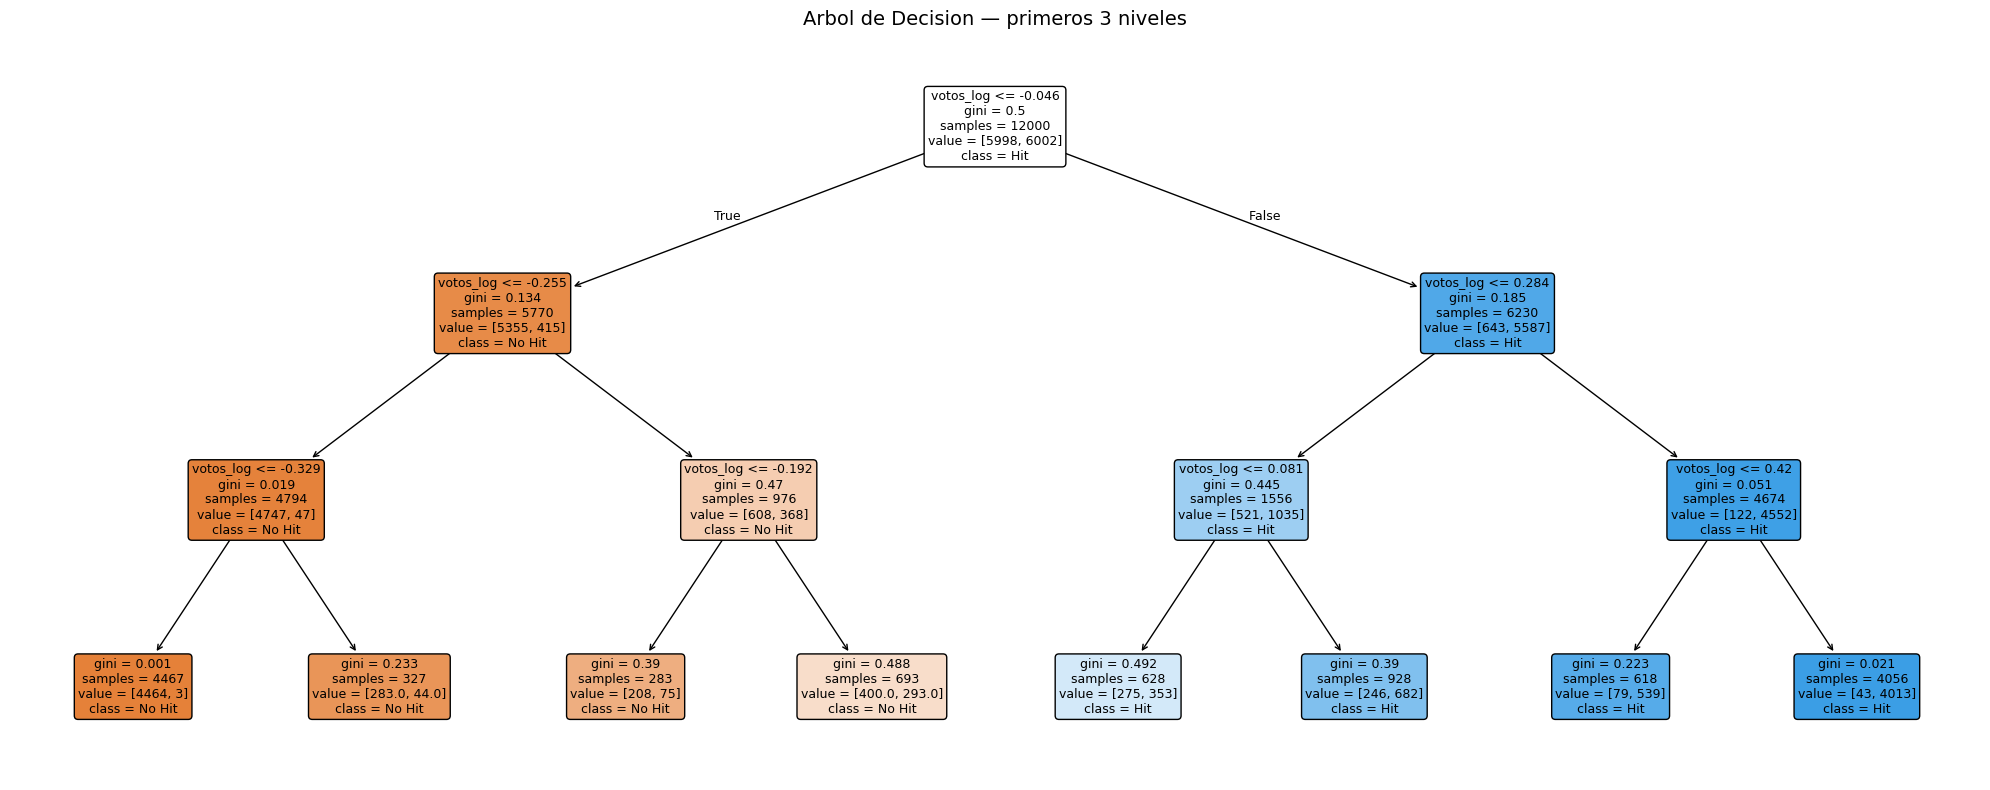

Figura guardada.


In [ ]:
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    mejor_dt,
    max_depth=3,
    feature_names=nombres_features,
    class_names=['No Hit', 'Hit'],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
)
ax.set_title('Arbol de Decision — primeros 3 niveles', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/10_arbol_decision.png', dpi=150, bbox_inches='tight')

## 4. Importancia de features

**Hallazgo clave:** `votos_log` domina completamente el modelo porque en este dataset
`hours_watched_million` e `imdb_votes` tienen una correlacion de 0.90. El numero de votos
en IMDb es esencialmente un proxy del exito comercial en la plataforma.

Con solo 3 niveles de profundidad, el arbol identifica umbrales en `votos_log` que
separan hits de no-hits con 91% de precision. Las demas features tienen correlacion
menor a 0.02 con `is_hit` y no aportan informacion adicional.

In [ ]:
importancias = pd.Series(mejor_dt.feature_importances_, index=nombres_features)

# Mostrar todas las features ordenadas — la dominancia de votos_log es el hallazgo
todas = importancias.sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
colores = ['steelblue' if v > 0 else 'lightgray' for v in todas]
todas.plot(kind='barh', ax=ax, color=colores)
ax.set_xlabel('Importancia')
ax.set_title('Importancia de features — Arbol de Decision')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('../reports/figures/11_importancias_dt.png', dpi=150, bbox_inches='tight')
plt.show()

print('Features con importancia > 0:')
print(importancias[importancias > 0].sort_values(ascending=False).to_string())

## 5. Metricas en test

In [ ]:
y_pred = mejor_dt.predict(X_test)
metricas_dt = mostrar_metricas(y_test, y_pred, 'Arbol de Decision')

In [ ]:
graficar_confusion(y_test, y_pred, 'Arbol de Decision', labels=['No Hit', 'Hit'])

In [ ]:
y_proba = mejor_dt.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)
print(f'ROC-AUC: {auc:.4f}')

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_proba, name='Arbol de Decision', ax=ax)
ax.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
ax.set_title('Curva ROC — Arbol de Decision')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/12_roc_dt.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Guardar modelo

In [ ]:
joblib.dump(mejor_dt, '../models/decision_tree.joblib')
print('Modelo guardado: models/decision_tree.joblib')

metricas_dt['roc_auc'] = round(auc, 4)
print(metricas_dt)